Árvore inicial (arestas):
[(0, 1), (0, 2), (1, 3), (1, 4), (2, 5), (2, 6)]

NDDR inicial:
0 (0, 0, 2)
1 (1, 1, 3)
2 (3, 2, 1)
3 (4, 2, 1)
4 (2, 1, 3)
5 (5, 2, 1)
6 (6, 2, 1)

Árvore após Operation 1 (arestas):
[(0, 1), (0, 2), (1, 3), (2, 5), (2, 6), (2, 4)]

NDDR após Operation 1:
0 (0, 0, 2)
1 (1, 1, 2)
2 (3, 2, 1)
3 (2, 1, 4)
4 (5, 2, 1)
5 (6, 2, 1)
6 (4, 2, 1)


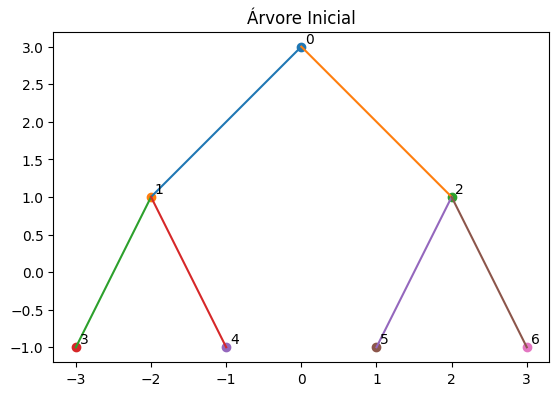

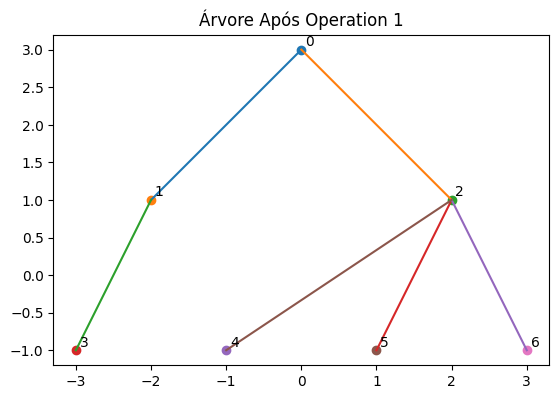

In [3]:
# Teste de mesa NDDR – Operation 1 (subtree transfer)
# Exemplo exatamente igual ao descrito na explicação anterior

import matplotlib.pyplot as plt
import math

# -----------------------------
# 1) Definição do grafo (posições fixas só para plot)
# -----------------------------

positions = {
    0: (0, 3),
    1: (-2, 1),
    2: (2, 1),
    3: (-3, -1),
    4: (-1, -1),
    5: (1, -1),
    6: (3, -1),
}

# Arestas iniciais da árvore
edges_before = [
    (0,1),
    (0,2),
    (1,3),
    (1,4),
    (2,5),
    (2,6)
]

# -----------------------------
# 2) Função para gerar NDDR via DFS
# -----------------------------

def generate_nddr(root, edges):
    # construir adjacência
    adj = {}
    for u,v in edges:
        adj.setdefault(u, []).append(v)
        adj.setdefault(v, []).append(u)

    visited = set()
    nddr = []

    def dfs(node, depth):
        visited.add(node)
        degree = len(adj[node])
        nddr.append((node, depth, degree))
        for neigh in adj[node]:
            if neigh not in visited:
                dfs(neigh, depth+1)

    dfs(root, 0)
    return nddr


# -----------------------------
# 3) Estado inicial
# -----------------------------

print("Árvore inicial (arestas):")
print(edges_before)

nddr_before = generate_nddr(0, edges_before)

print("\nNDDR inicial:")
for idx, triple in enumerate(nddr_before):
    print(idx, triple)

# -----------------------------
# 4) Operation 1: mover nó 4 para ser filho de 2
# remove (1,4) e adiciona (2,4)
# -----------------------------

edges_after = [
    (0,1),
    (0,2),
    (1,3),
    # (1,4) removida
    (2,5),
    (2,6),
    (2,4)  # nova aresta
]

print("\nÁrvore após Operation 1 (arestas):")
print(edges_after)

nddr_after = generate_nddr(0, edges_after)

print("\nNDDR após Operation 1:")
for idx, triple in enumerate(nddr_after):
    print(idx, triple)

# -----------------------------
# 5) Plot da árvore inicial
# -----------------------------

plt.figure()
for (u,v) in edges_before:
    x = [positions[u][0], positions[v][0]]
    y = [positions[u][1], positions[v][1]]
    plt.plot(x,y)

for node,(x,y) in positions.items():
    plt.scatter(x,y)
    plt.text(x+0.05,y+0.05,str(node))

plt.title("Árvore Inicial")
plt.gca().set_aspect('equal')
plt.show()


# -----------------------------
# 6) Plot da árvore após mutação
# -----------------------------

plt.figure()
for (u,v) in edges_after:
    x = [positions[u][0], positions[v][0]]
    y = [positions[u][1], positions[v][1]]
    plt.plot(x,y)

for node,(x,y) in positions.items():
    plt.scatter(x,y)
    plt.text(x+0.05,y+0.05,str(node))

plt.title("Árvore Após Operation 1")
plt.gca().set_aspect('equal')
plt.show()


Pai 1 - NDDR
0 (0, 0, 2)
1 (1, 1, 4)
2 (5, 2, 1)
3 (3, 2, 1)
4 (4, 2, 1)
5 (2, 1, 2)
6 (6, 2, 1)

Pai 2 - NDDR
0 (0, 0, 2)
1 (1, 1, 4)
2 (4, 2, 1)
3 (3, 2, 1)
4 (5, 2, 1)
5 (2, 1, 2)
6 (6, 2, 1)


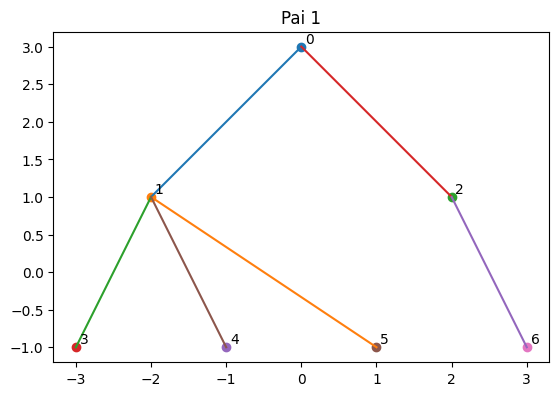

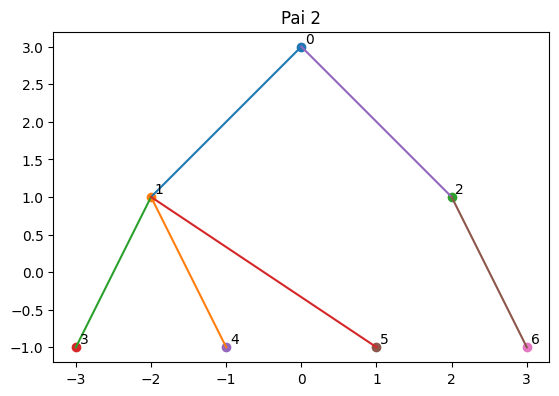


Subárvore escolhida do Pai 1: [6]
Subárvore escolhida do Pai 2: [2, 6]

Filho após cruzamento (NDDR modificado):
0 (0, 0, 2)
1 (1, 1, 4)
2 (5, 2, 1)
3 (3, 2, 1)
4 (4, 2, 1)
5 (2, 1, 2)
6 (2, 1, 2)


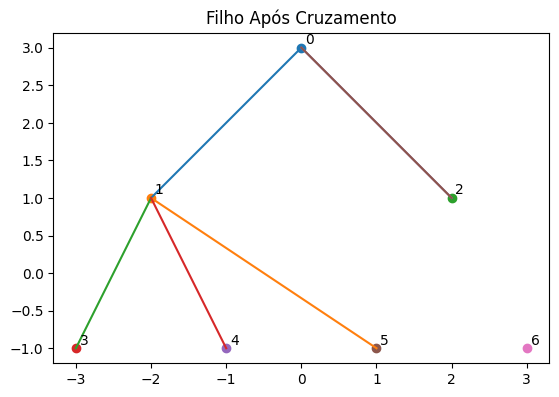


Filho após mutação (NDDR):
0 (0, 0, 2)
1 (2, 1, 2)


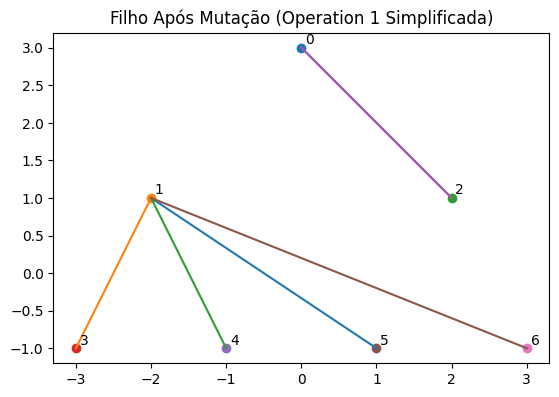

In [5]:
# ================================================
# NDDR - Cruzamento e Mutação (P2 - árvore discreta)
# ================================================

import random
import matplotlib.pyplot as plt

# ------------------------------
# Grafo base fixo (mesmo do exemplo)
# ------------------------------

positions = {
    0: (0, 3),
    1: (-2, 1),
    2: (2, 1),
    3: (-3, -1),
    4: (-1, -1),
    5: (1, -1),
    6: (3, -1),
}

base_edges = [
    (0,1),(0,2),
    (1,3),(1,4),
    (2,5),(2,6),
    (2,4),(1,5)  # arestas extras possíveis
]

nodes = list(positions.keys())

# ------------------------------
# Funções auxiliares
# ------------------------------

def plot_tree(edges, title):
    plt.figure()
    for (u,v) in edges:
        x = [positions[u][0], positions[v][0]]
        y = [positions[u][1], positions[v][1]]
        plt.plot(x,y)
    for node,(x,y) in positions.items():
        plt.scatter(x,y)
        plt.text(x+0.05,y+0.05,str(node))
    plt.title(title)
    plt.gca().set_aspect('equal')
    plt.show()


def generate_random_tree():
    visited = {0}
    edges = []
    while len(visited) < len(nodes):
        possible = [e for e in base_edges if (e[0] in visited) ^ (e[1] in visited)]
        e = random.choice(possible)
        edges.append(e)
        visited.add(e[0])
        visited.add(e[1])
    return edges


def generate_nddr(root, edges):
    adj = {}
    for u,v in edges:
        adj.setdefault(u, []).append(v)
        adj.setdefault(v, []).append(u)
    visited = set()
    nddr = []
    def dfs(node, depth):
        visited.add(node)
        degree = len(adj[node])
        nddr.append((node, depth, degree))
        for neigh in adj[node]:
            if neigh not in visited:
                dfs(neigh, depth+1)
    dfs(root,0)
    return nddr


def subtree_nodes(nddr, idx):
    node, depth, _ = nddr[idx]
    result = [node]
    i = idx + 1
    while i < len(nddr) and nddr[i][1] > depth:
        result.append(nddr[i][0])
        i += 1
    return result


def tree_from_parent(parent):
    edges = []
    for i in range(1,len(parent)):
        node, depth, _ = parent[i]
        for j in range(i-1,-1,-1):
            if parent[j][1] == depth-1:
                edges.append((node,parent[j][0]))
                break
    return edges


# ------------------------------
# 1) Gerar dois pais aleatórios
# ------------------------------

parent1_edges = generate_random_tree()
parent2_edges = generate_random_tree()

parent1_nddr = generate_nddr(0,parent1_edges)
parent2_nddr = generate_nddr(0,parent2_edges)

print("Pai 1 - NDDR")
for i,x in enumerate(parent1_nddr):
    print(i,x)

print("\nPai 2 - NDDR")
for i,x in enumerate(parent2_nddr):
    print(i,x)

plot_tree(parent1_edges,"Pai 1")
plot_tree(parent2_edges,"Pai 2")


# ------------------------------
# 2) Cruzamento (troca de subárvore)
# ------------------------------

# Escolhe índice aleatório (não raiz)
idx1 = random.randint(1,len(parent1_nddr)-1)
idx2 = random.randint(1,len(parent2_nddr)-1)

sub1 = subtree_nodes(parent1_nddr, idx1)
sub2 = subtree_nodes(parent2_nddr, idx2)

print("\nSubárvore escolhida do Pai 1:", sub1)
print("Subárvore escolhida do Pai 2:", sub2)

# Cruzamento simples: troca nós mantendo profundidades
child_nddr = parent1_nddr.copy()

# substitui nó raiz da subárvore
node_to_replace = child_nddr[idx1][0]
replacement = parent2_nddr[idx2]

child_nddr[idx1] = replacement

print("\nFilho após cruzamento (NDDR modificado):")
for i,x in enumerate(child_nddr):
    print(i,x)

child_edges = tree_from_parent(child_nddr)

plot_tree(child_edges,"Filho Após Cruzamento")


# ------------------------------
# 3) Mutação (Operation 1 simplificada)
# ------------------------------

mut_edges = child_edges.copy()

# remove aresta aleatória e reconecta folha aleatória
u,v = random.choice(mut_edges)
mut_edges.remove((u,v))

# escolhe novo nó pai aleatório
leaf = u
possible_parents = [n for n in nodes if n != leaf]
new_parent = random.choice(possible_parents)
mut_edges.append((leaf,new_parent))

mut_nddr = generate_nddr(0,mut_edges)

print("\nFilho após mutação (NDDR):")
for i,x in enumerate(mut_nddr):
    print(i,x)

plot_tree(mut_edges,"Filho Após Mutação (Operation 1 Simplificada)")
